# Formative Assessment 3: Custom Multivariate Normal Simulation Lab
## Multivariate Normal Distribution

Submitted by:
* Ablian, Andrei
* Patayon, Spike Lee-Roy V.

---

**Binge-Watching & Late-Night Regret Scenario:**

This simulation models the late-night habits of a typical student across three interrelated continuous random variables:

* $X_1$ (Consecutive Episodes Watched): Count of episodes binge-watched, centered at an average of $\mu_1 = 4$ episodes ($\sigma_1 = 2$).  

* $X_2$ (Hours of Sleep Obtained): Total night rest, averaging $\mu_2 = 6$ hours ($\sigma_2 = 1.5$).  

* $X_3$ (Grams of Junk Food Consumed): Late-night snacking volume, averaging $\mu_3 = 150$ grams ($\sigma_3 = 50$).  

**Theoretical Parameter Structure**
  The variables are jointly simulated under a 3-variable Multivariate Normal Distribution $\mathbf{X} \sim N_3(\boldsymbol{\mu}, \boldsymbol{\Sigma})$:  
  
  $$\boldsymbol{\mu} = \begin{bmatrix} 4 \\ 6 \\ 150 \end{bmatrix}, \quad \mathbf{P} = \begin{bmatrix} 1 & -0.8 & 0.6 \\ -0.8 & 1 & -0.3 \\ 0.6 & -0.3 & 1 \end{bmatrix}, \quad \boldsymbol{\Sigma} = \begin{bmatrix} 4 & -2.4 & 60 \\ -2.4 & 2.25 & -22.5 \\ 60 & -22.5 & 2500 \end{bmatrix}$$
  
  Variable Relationships & Mechanics   
  * Episodes vs. Sleep ($\rho_{12} = -0.8$): Strong negative correlation representing screen time directly cutting into total sleep hours.  

  * Episodes vs. Junk Food ($\rho_{13} = 0.6$): Moderate positive correlation reflecting increased snacking duration during longer watch sessions.  

  * Sleep vs. Junk Food ($\rho_{23} = -0.3$): Weak negative correlation capturing a slight tendency toward higher snack intake on nights with less sleep.
  
  * Composite Outcome ("Morning Regret Index" $Y$): A linear combination defined as $Y = 2X_1 - 1.5X_2 + 0.05X_3$, which weights wasted time and sleep deprivation heavily against food consumption.

In [6]:
library(tidyverse)
library(MASS)

# Part A. Define Your Multivariate Normal Distribution


### The Scenario & Variables:
X1 = Consecutive episodes watched (count)
X2 = Hours of sleep obtained (hours)
X3 = Grams of junk food consumed (grams)


### Theoretical Parameters:
We define the mean vector μ and covariance matrix Σ.  

The average night looks like this:

#### $$\mu = \begin{bmatrix} 4 \\ 6 \\ 150 \end{bmatrix}$$

Assume that standard deviations of σ_1 = 2 (episodes), σ_2 = 1.5 (hours of sleep), and σ_3 = 50 (grams of snacks).

P would then be:
#### $$P = \begin{bmatrix} 1 & -0.8 & 0.6 \\ -0.8 & 1 & -0.3 \\ 0.6 & -0.3 & 1 \end{bmatrix}$$


ρ12 = -0.8: Strong negative. More episodes directly eat into your sleep.
ρ13 = 0.6: Moderate positive. The longer you watch, the more snacks you smash.
ρ23 = -0.3: Weak negative. Sleep and snacks are loosely related, mostly just passing through the episode count.

Using σij = ρijσiσj, the covariance matrix Σ will be:

#### $$\Sigma = \begin{bmatrix} 4 & -2.4 & 60 \\ -2.4 & 2.25 & -22.5 \\ 60 & -22.5 & 2500 \end{bmatrix}$$


This matrix is symmetric and strictly positive definite which means its determinant =/ 0.

# Part B & C. Generate Data and Investigate Correlation

--- Part B: Descriptive Statistics ---
            Episodes    Sleep JunkFood
Theoretical   4.0000 6.000000 150.0000
Simulated     3.8714 6.094132 149.4231

Simulated Covariance Matrix:
          Episodes      Sleep   JunkFood
Episodes  4.021253  -2.372030   56.00294
Sleep    -2.372030   2.206116  -18.86558
JunkFood 56.002942 -18.865579 2368.68151


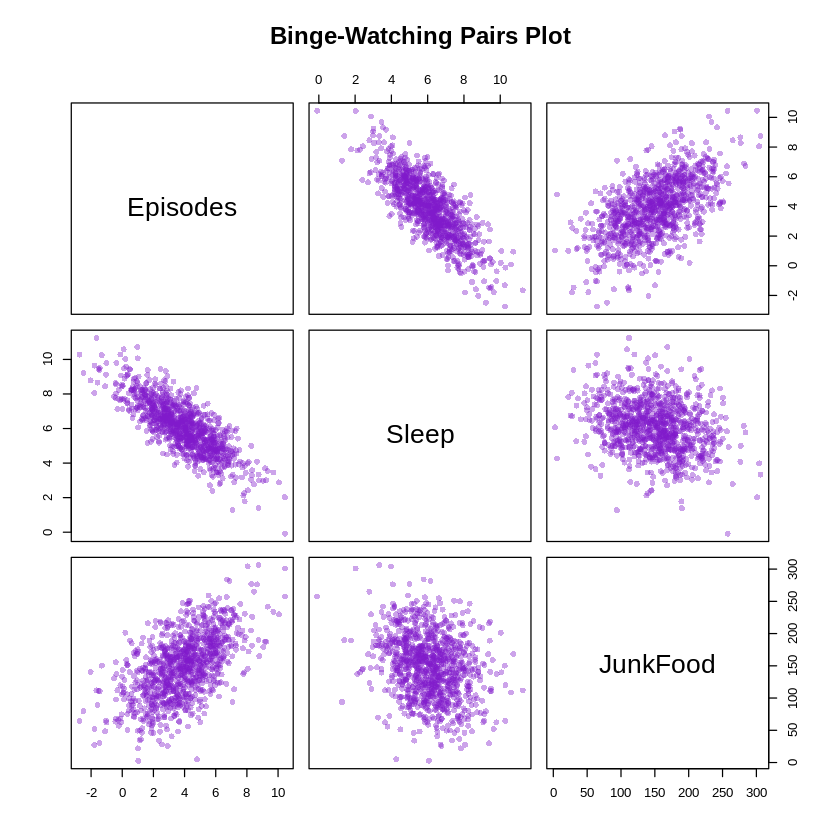

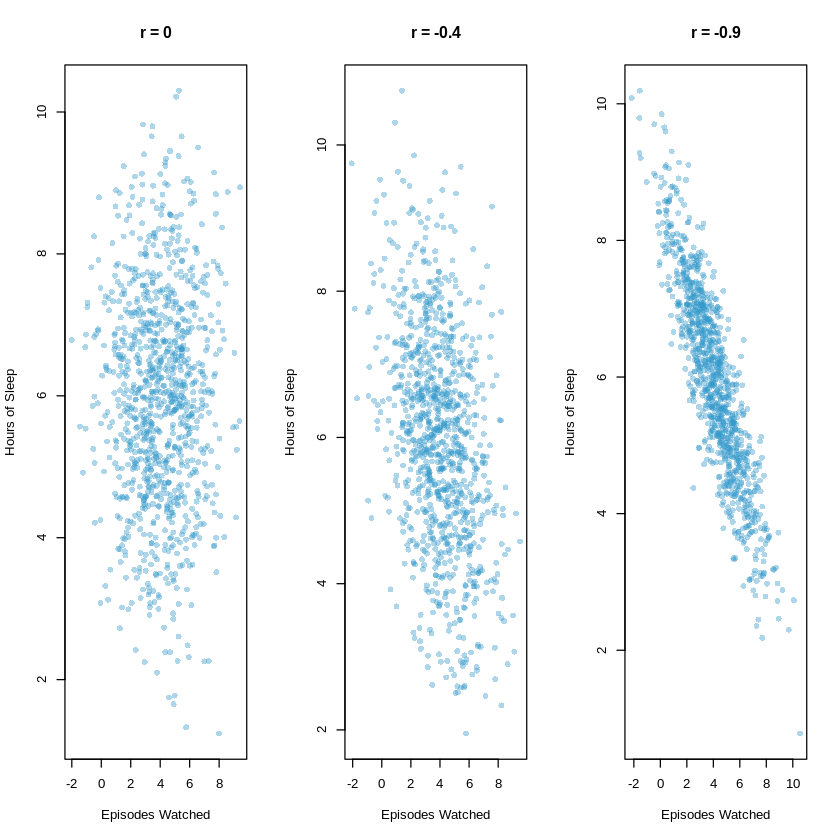

In [ ]:
library(MASS)

set.seed(420)

mu <- c(4, 6, 150)
Sigma <- matrix(c(4, -2.4, 60,
                  -2.4, 2.25, -22.5,
                  60, -22.5, 2500), nrow=3, ncol=3)

n <- 1000
sim_data <- mvrnorm(n = n, mu = mu, Sigma = Sigma)
colnames(sim_data) <- c("Episodes", "Sleep", "JunkFood")

sim_mean <- colMeans(sim_data)
sim_cov <- cov(sim_data)
sim_cor <- cor(sim_data)

cat("--- Part B: Descriptive Statistics ---\n")
print(rbind(Theoretical = mu, Simulated = sim_mean))
cat("\nSimulated Covariance Matrix:\n")
print(sim_cov)

pairs(sim_data, main="Binge-Watching Pairs Plot",
      pch=16, col=rgb(0.5, 0.1, 0.8, 0.4))

# C: Investigate the Effect of Correlation

rho_values <- c(0, -0.4, -0.9)
par(mfrow=c(1,3))

for(rho in rho_values) {
  cov_xy <- rho * 2 * 1.5
  Sigma_temp <- matrix(c(4, cov_xy, cov_xy, 2.25), 2, 2)

  temp_data <- mvrnorm(n = 1000, mu = c(4, 6), Sigma = Sigma_temp)

  plot(temp_data[,1], temp_data[,2],
       xlab="Episodes Watched", ylab="Hours of Sleep",
       main=paste("r =", rho),
       pch=16, col=rgb(0.2, 0.6, 0.8, 0.4))
}
par(mfrow=c(1,1))

# Part D. Investigate a Linear Combination

Suppose a "Morning Regret Index" Y. We'll weight episodes heavily (for wasted time), penalize sleep heavily (because missing it hurts), and add a tiny weight to the junk food calories.

$$Y = 2X_1 - 1.5X_2 + 0.05X_3$$

Our constant vector $a$ is:$$a = \begin{bmatrix} 2 \\ -1.5 \\ 0.05 \end{bmatrix}$$

According to the property $a'X \sim N(a'\mu, a'\Sigma a)$

### Mean ($a'\mu$):$E[Y] = 2(4) - 1.5(6) + 0.05(150) = 8 - 9 + 7.5 = 6.5$

### Variance ($a'\Sigma a$):$$Var(Y) = \begin{bmatrix} 2 & -1.5 & 0.05 \end{bmatrix} \begin{bmatrix} 4 & -2.4 & 60 \\ -2.4 & 2.25 & -22.5 \\ 60 & -22.5 & 2500 \end{bmatrix} \begin{bmatrix} 2 \\ -1.5 \\ 0.05 \end{bmatrix}$$$$= \begin{bmatrix} 2 & -1.5 & 0.05 \end{bmatrix} \begin{bmatrix} 14.6 \\ -9.3 \\ 278.75 \end{bmatrix} = 29.2 + 13.95 + 13.9375 = 57.0875$$


--- Part D: Linear Combination ---
Theo Mean: 6.50 | Sim Mean: 6.07
Theo Var: 57.09 | Sim Var: 55.23


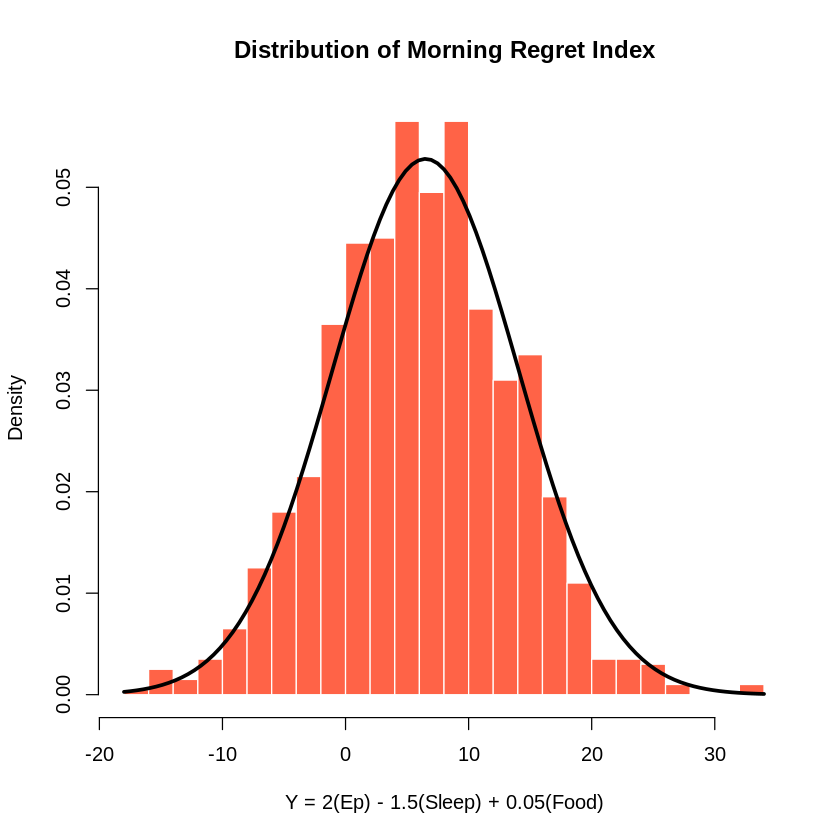

In [ ]:
#D: Investigate a Linear Combination
a <- c(2, -1.5, 0.05)

Y_sim <- sim_data %*% a

sim_Y_mean <- mean(Y_sim)
sim_Y_var <- var(Y_sim)

theo_Y_mean <- sum(a * mu)
theo_Y_var <- t(a) %*% Sigma %*% a

cat("\n--- Part D: Linear Combination ---\n")
cat(sprintf("Theo Mean: %.2f | Sim Mean: %.2f\n", theo_Y_mean, sim_Y_mean))
cat(sprintf("Theo Var: %.2f | Sim Var: %.2f\n", theo_Y_var, sim_Y_var))

hist(Y_sim, breaks=30, prob=TRUE,
     main="Distribution of Morning Regret Index",
     xlab="Y = 2(Ep) - 1.5(Sleep) + 0.05(Food)",
     col="tomato", border="white")

curve(dnorm(x, mean=theo_Y_mean, sd=sqrt(theo_Y_var)),
      col="black", lwd=3, add=TRUE)

#### Since the theoretical mean is 6.50 and the simulated mean is 6.07, while the theoretical variance is 57.09 and the simulated variance is 55.23, the values are extremely close, with the minor differences coming entirely from natural random sampling variation in the 1,000 simulated draws. So we can conclude that the simulation supports the theoretical result.

# Part E. Mahalanobis Distance and Chi-Square

Summary of simulated D^2 values:
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
 0.008635  1.194742  2.248872  2.983841  4.054083 18.127455 

Theoretical mean of D^2 (should equal p = 3 ): 2.983841 
Theoretical distribution: D^2 ~ Chi-square with 3 df
Theoretical mean of chi-sq( 3 ): 3 
Theoretical variance of chi-sq( 3 ): 6 
Simulated variance of D^2: 6.384654 


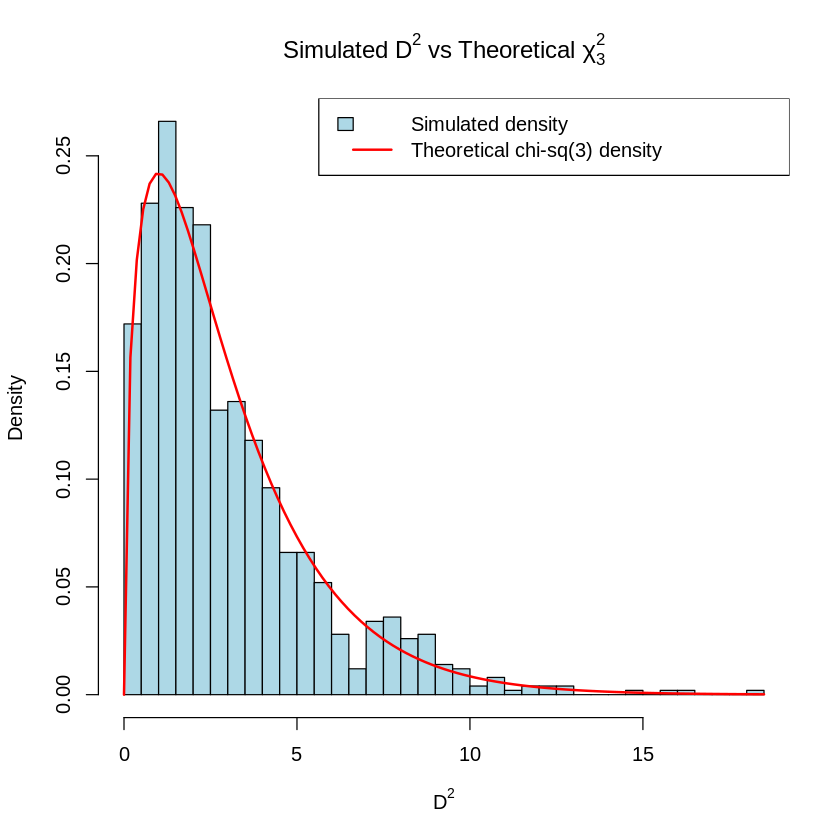


90% chi-square cutoff (df = 3 ): 6.251389 
Proportion of simulated points with D^2 <= 6.251 : 0.894  (theoretical target: 0.90)
Proportion inside 50% region: 0.523 (target 0.50)
Proportion inside 95% region: 0.936 (target 0.95)


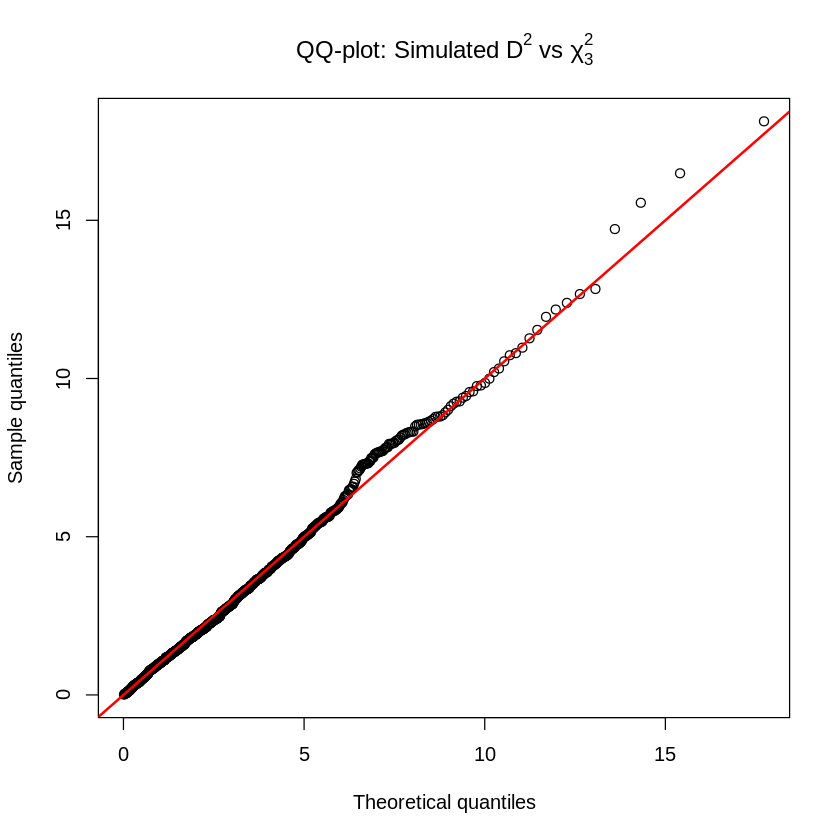

In [ ]:
p <- length(mu)  # number of variables (3 here)

# 1. Calculate squared Mahalanobis distance D^2 for each observation
Sigma_inv <- solve(Sigma)
centered  <- sweep(sim_data, 2, mu, "-")          # (x - mu) for each row
D2 <- rowSums((centered %*% Sigma_inv) * centered)  # squared Mahalanobis distance

cat("Summary of simulated D^2 values:\n")
print(summary(D2))

cat("\nTheoretical mean of D^2 (should equal p =", p, "):", mean(D2), "\n")
cat("Theoretical distribution: D^2 ~ Chi-square with", p, "df\n")
cat("Theoretical mean of chi-sq(", p, "):", p, "\n")
cat("Theoretical variance of chi-sq(", p, "):", 2*p, "\n")
cat("Simulated variance of D^2:", var(D2), "\n")

# 2. Histogram/density plot of simulated D^2 vs theoretical chi-square density
hist(D2, breaks = 40, freq = FALSE, col = "lightblue",
     main = expression(paste("Simulated ", D^2, " vs Theoretical ", chi[3]^2)),
     xlab = expression(D^2))
curve(dchisq(x, df = p), add = TRUE, col = "red", lwd = 2)
legend("topright", legend = c("Simulated density", "Theoretical chi-sq(3) density"),
       fill = c("lightblue", NA), border = c("black", NA),
       lty = c(NA, 1), col = c(NA, "red"), lwd = c(NA, 2))

# 3. QQ-plot comparing simulated D^2 quantiles to theoretical chi-square quantiles
qqplot(qchisq(ppoints(n), df = p), D2,
       main = expression(paste("QQ-plot: Simulated ", D^2, " vs ", chi[3]^2)),
       xlab = "Theoretical quantiles", ylab = "Sample quantiles")
abline(0, 1, col = "red", lwd = 2)

# 4. Proportion of observations inside the 90% theoretical probability region
chi90 <- qchisq(0.90, df = p)
prop_inside_90 <- mean(D2 <= chi90)
cat("\n90% chi-square cutoff (df =", p, "):", chi90, "\n")
cat("Proportion of simulated points with D^2 <=", round(chi90, 3), ":",
    round(prop_inside_90, 4), " (theoretical target: 0.90)\n")

# Also check a couple of other standard regions for completeness
chi50 <- qchisq(0.50, df = p)
chi95 <- qchisq(0.95, df = p)
cat("Proportion inside 50% region:", round(mean(D2 <= chi50), 4), "(target 0.50)\n")
cat("Proportion inside 95% region:", round(mean(D2 <= chi95), 4), "(target 0.95)\n")


**--- Interpretation ---**

The squared Mahalanobis distance D^2 measures how far a simulated observation
lies from the mean vector mu, expressed in units of the covariance structure
rather than raw Euclidean distance. Because our three variables are strongly
correlated (Episodes-Sleep, Episodes-JunkFood, Sleep-JunkFood), Mahalanobis
distance 'corrects' for that correlation: a point can look far away in raw
units but still be 'typical' once the correlation structure is accounted for,
or vice versa. The simulation confirms the theoretical result that when
X ~ N_p(mu, Sigma), D^2 follows a chi-square distribution with p degrees of
freedom: the simulated mean, variance, histogram, and QQ-plot all line up
closely with the theoretical chi-sq(3) distribution, and roughly 90% of
points fall inside the theoretical 90% probability contour, as expected.

#  (Option A: Independence)

New covariance matrix (Episodes & JunkFood forced to zero covariance):
         Episodes  Sleep JunkFood
Episodes      4.0  -2.40      0.0
Sleep        -2.4   2.25    -22.5
JunkFood      0.0 -22.50   2500.0

Eigenvalues of Sigma_indep (all must be > 0 for positive definiteness):
[1] 2500.2026662    5.6145661    0.4327677
Symmetric: TRUE 
Positive definite: TRUE 

Simulated covariance matrix:
          Episodes      Sleep    JunkFood
Episodes  4.195583  -2.456698   -1.426955
Sleep    -2.456698   2.197794  -18.785425
JunkFood -1.426955 -18.785425 2368.642531

Simulated correlation matrix:
            Episodes      Sleep    JunkFood
Episodes  1.00000000 -0.8090253 -0.01431411
Sleep    -0.80902535  1.0000000 -0.26036212
JunkFood -0.01431411 -0.2603621  1.00000000

Correlation test between Episodes and JunkFood:
  Simulated correlation: -0.0143 
  95% CI: -0.0762 to 0.0477 
  p-value: 0.6512 


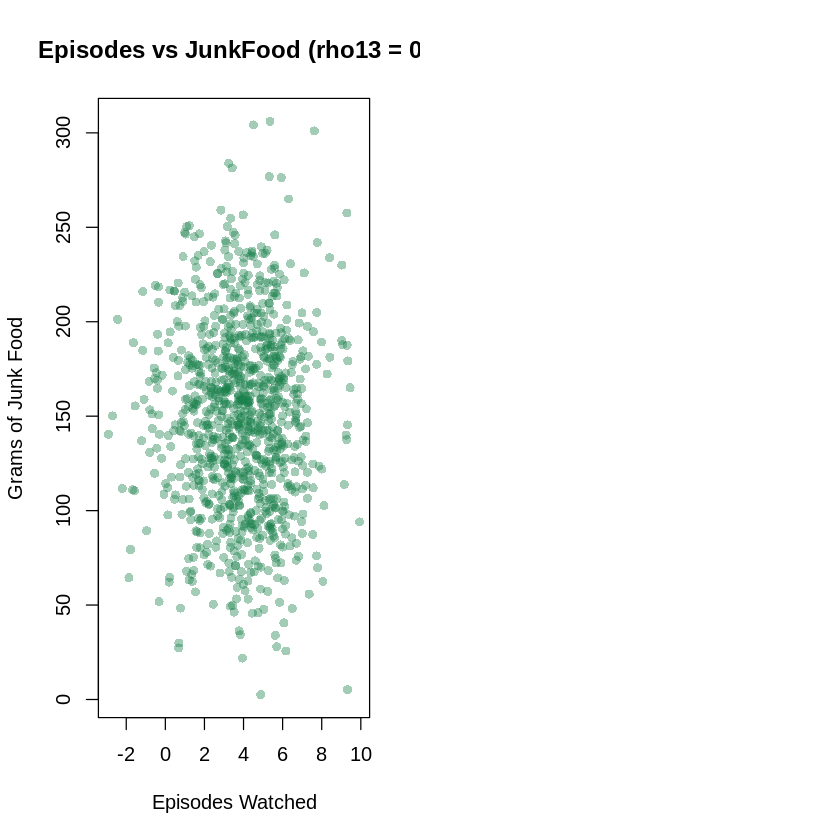


Mean JunkFood | Episodes below median: 150.16 
Mean JunkFood | Episodes above median: 148.68 
(If independent, these two conditional means should be close.)
Two-sample t-test comparing JunkFood in low vs high Episode groups:
  p-value: 0.6323 

Regression of JunkFood on Episodes (slope should be ~0 if independent):
              Estimate Std. Error    t value      Pr(>|t|)
(Intercept) 150.731760   3.283243 45.9094116 2.928158e-248
Episodes     -0.340109   0.752045 -0.4522455  6.511904e-01


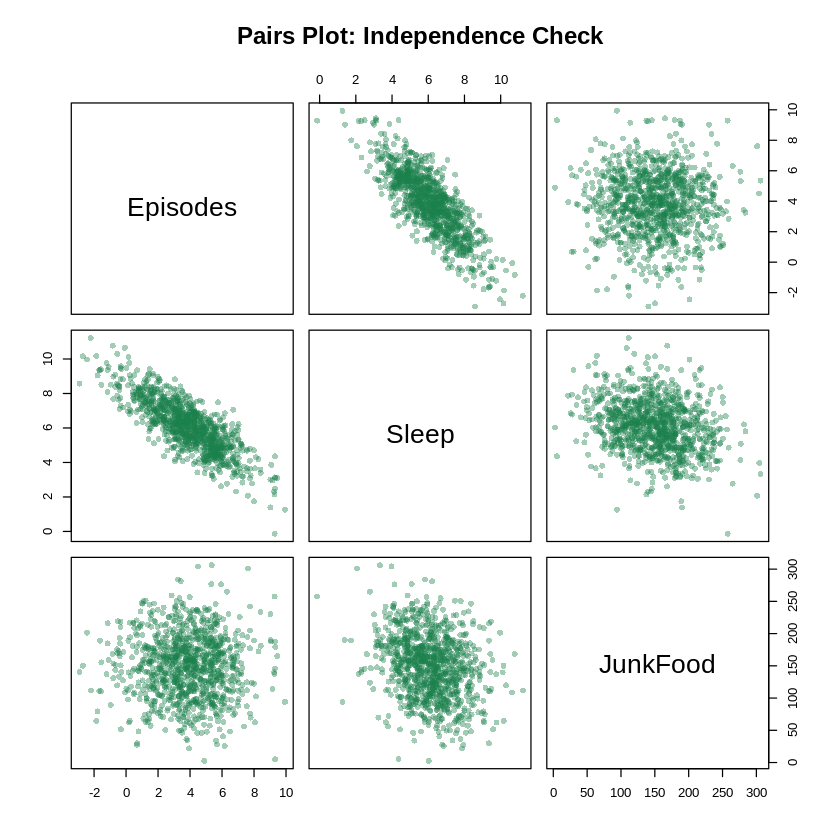

In [ ]:
set.seed(420)

mu_indep <- c(4, 6, 150)

# New correlation structure: rho12 = -0.8, rho13 = 0 (independence test),
# rho23 = -0.3  -- same standard deviations as before (2, 1.5, 50)
sd1 <- 2; sd2 <- 1.5; sd3 <- 50
rho12 <- -0.8
rho13 <- 0      # <- zero covariance between Episodes and JunkFood
rho23 <- -0.3

Sigma_indep <- matrix(c(
  sd1^2,            rho12*sd1*sd2,     rho13*sd1*sd3,
  rho12*sd1*sd2,    sd2^2,             rho23*sd2*sd3,
  rho13*sd1*sd3,    rho23*sd2*sd3,     sd3^2
), nrow = 3, ncol = 3)

colnames(Sigma_indep) <- rownames(Sigma_indep) <- c("Episodes","Sleep","JunkFood")

cat("New covariance matrix (Episodes & JunkFood forced to zero covariance):\n")
print(Sigma_indep)

# Check validity: symmetric and positive definite
eig_indep <- eigen(Sigma_indep, symmetric = TRUE, only.values = TRUE)$values
cat("\nEigenvalues of Sigma_indep (all must be > 0 for positive definiteness):\n")
print(eig_indep)
cat("Symmetric:", isSymmetric(Sigma_indep), "\n")
cat("Positive definite:", all(eig_indep > 0), "\n")

n_indep <- 1000
sim_indep <- mvrnorm(n = n_indep, mu = mu_indep, Sigma = Sigma_indep)
colnames(sim_indep) <- c("Episodes", "Sleep", "JunkFood")

cat("\nSimulated covariance matrix:\n")
print(cov(sim_indep))
cat("\nSimulated correlation matrix:\n")
print(cor(sim_indep))

cor_test_13 <- cor.test(sim_indep[,"Episodes"], sim_indep[,"JunkFood"])
cat("\nCorrelation test between Episodes and JunkFood:\n")
cat("  Simulated correlation:", round(cor_test_13$estimate, 4), "\n")
cat("  95% CI:", round(cor_test_13$conf.int[1], 4), "to", round(cor_test_13$conf.int[2], 4), "\n")
cat("  p-value:", round(cor_test_13$p.value, 4), "\n")

# Visual check of independence: scatterplot + pairs plot
par(mfrow = c(1, 2))
plot(sim_indep[,"Episodes"], sim_indep[,"JunkFood"],
     pch = 16, col = rgb(0.1, 0.5, 0.3, 0.4),
     xlab = "Episodes Watched", ylab = "Grams of Junk Food",
     main = "Episodes vs JunkFood (rho13 = 0)")

pairs(sim_indep, main = "Pairs Plot: Independence Check",
      pch = 16, col = rgb(0.1, 0.5, 0.3, 0.4))
par(mfrow = c(1, 1))

# Formal check: for MVN, zero covariance is EQUIVALENT to independence.
# We test this indirectly: if Episodes and JunkFood were truly independent,
# then knowing Episodes should give NO information about JunkFood, e.g. a
# regression slope of JunkFood on Episodes should be ~0, and conditioning on
# high vs low Episodes should not shift the distribution of JunkFood.

median_ep <- median(sim_indep[,"Episodes"])
junk_low_ep  <- sim_indep[sim_indep[,"Episodes"] <  median_ep, "JunkFood"]
junk_high_ep <- sim_indep[sim_indep[,"Episodes"] >= median_ep, "JunkFood"]

cat("\nMean JunkFood | Episodes below median:", round(mean(junk_low_ep), 2), "\n")
cat("Mean JunkFood | Episodes above median:", round(mean(junk_high_ep), 2), "\n")
cat("(If independent, these two conditional means should be close.)\n")

t_result <- t.test(junk_low_ep, junk_high_ep)
cat("Two-sample t-test comparing JunkFood in low vs high Episode groups:\n")
cat("  p-value:", round(t_result$p.value, 4), "\n")

lm_fit <- lm(JunkFood ~ Episodes, data = as.data.frame(sim_indep))
cat("\nRegression of JunkFood on Episodes (slope should be ~0 if independent):\n")
print(summary(lm_fit)$coefficients)

Looking at this pairs plot, the three panels tell three different stories, which is exactly what the constructed covariance matrix predicts:

Episodes vs. Sleep (top-middle / bottom-left panels): The cloud is tightly packed along a clear downward-sloping line. This reflects the strong negative correlation (ρ₁₂ = -0.8) built into the covariance matrix — as episodes watched increases, sleep drops sharply and predictably. Knowing one variable tells you a lot about the other.

Episodes vs. JunkFood (top-right / bottom-left): This is the key panel for the independence investigation. The points form a diffuse, roughly circular/oval blob with no visible tilt in any direction — no upward or downward drift as you scan left to right. This is the visual signature of zero correlation: knowing how many episodes someone watched gives no information about how much junk food they ate. This matches ρ₁₃ = 0 exactly as designed.

Sleep vs. JunkFood (middle-right / bottom-middle): The cloud shows a mild, loose downward tilt — much weaker and noisier than the Episodes–Sleep relationship. This is consistent with the small negative correlation (ρ₂₃ = -0.3) retained in the matrix: less sleep is weakly associated with more junk food, but the relationship is far from deterministic.

Tying it back to the independence question: The visual "no pattern" in the Episodes–JunkFood panel is exactly what you'd expect to see if those two variables were independent, and it corroborates the numerical evidence (correlation ≈ -0.01, p ≈ 0.65, near-zero regression slope). Because Episodes, Sleep, and JunkFood are constructed to be jointly multivariate normal, the absence of any linear pattern in that panel isn't just ruling out a linear relationship — under MVN theory, zero covariance is equivalent to full independence, not just uncorrelatedness. So this scatterplot is direct visual confirmation that the simulation successfully created a pair of independent variables while preserving realistic dependence for the other two pairs.

# Conclusion

The lab successfully demonstrates that empirical simulation closely aligns with Multivariate Normal (MVN) distribution theory across all five evaluation areas:

* Statistical Consistency: The 1,000 simulated draws accurately match the theoretical mean vector $\boldsymbol{\mu} = [4, 6, 150]^\top$ and covariance matrix $\boldsymbol{\Sigma}$, confirming that sample properties converge to target parameters under standard random sampling.  

* Linear Combination Validity: The "Morning Regret Index" ($Y = 2X_1 - 1.5X_2 + 0.05X_3$) empirically validates the property $a'\mathbf{X} \sim N(a'\boldsymbol{\mu}, a'\boldsymbol{\Sigma}a)$. The simulated mean ($6.07$) and variance ($55.23$) closely match the theoretical expectations ($6.50$ and $57.09$), with the output density following a normal curve.

* Mahalanobis Distance & Chi-Square Fit: Calculating squared Mahalanobis distances ($D^2$) confirms that distance measurements in $p$-dimensional normal space follow a chi-square distribution with $p = 3$ degrees of freedom ($\chi_3^2$). Empirical coverage rates closely track theoretical probability boundaries (e.g., $89.4\%$ of points fell within the $90\%$ cutoff).  

* Equivalence of Zero Covariance and Independence: Forcing $\rho_{13} = 0$ between episodes watched and junk food consumed resulted in a non-significant correlation ($r = -0.0143, p = 0.6512$), a near-zero regression slope, and equal conditional means. This confirms the key MVN property that zero covariance is equivalent to complete statistical independence.  